# Day 7 | Lab 7.2: Parallelization — Fan-Out / Fan-In with the Send API

**Duration:** ~1.5 hours

**Scenario.** Real-world parallel processing for a **financial compliance pipeline** (SecureBank-style framing preserved from the source). We progress from a baseline linear graph through static fan-out to dynamic fan-out with the `Send` API — and finish with an **empirical cost / latency comparison**.

**Learning Objectives.** By the end of this lab, you will be able to:
1. Build a baseline **linear graph** and observe the wall-clock time for sequential nodes.
2. Use **multiple outgoing edges from one node** to express **static fan-out / fan-in** with reducers.
3. Apply the LangGraph **`Send` API** for **dynamic fan-out** when the worker count is data-dependent.
4. Wire **fan-in reducers** (`operator.add`, custom merge functions) to deterministically combine concurrent updates.
5. Empirically measure the speedup of 4 parallel LLM calls vs 4 sequential calls — and articulate when parallelization is NOT a win.

**Tools.** LangGraph v1 · LangChain v1 · `langchain-openai` · `gpt-4.1-mini`.

*Created by Prashant Sahu · [LinkedIn](https://www.linkedin.com/in/prashantksahu/)*

---


## Setup: Install Dependencies

In [2]:
# Required packages for this lab — already installed in your local venv.
# To install standalone, uncomment the line(s) below:
# !pip install -q 'langchain>=1.0' 'langchain-core>=1.0' 'langgraph>=1.0' 'langchain-openai>=1.0'


In [3]:
import os

# Local-venv pattern: load from .env if python-dotenv is available, otherwise rely on
# environment variables already set in your shell or venv activation script.
try:
    from dotenv import load_dotenv
    load_dotenv("..\\.env")
except ImportError:
    pass

for key in ['OPENAI_API_KEY']:
    status = '✅ Loaded' if os.environ.get(key) else '❌ MISSING'
    print(f'{key}: {status}')


OPENAI_API_KEY: ✅ Loaded


## Import Libraries

In [4]:
import operator
from typing import Any, Annotated
from typing_extensions import TypedDict

from langgraph.graph import StateGraph, START, END
from IPython.display import Image, display

## Part 1: Simple Linear Graph (Baseline)

Before parallelizing, let's build a simple sequential graph where steps execute one after another: **A -> B -> C -> D**. This establishes the baseline pattern.

We define:
- A `State` with `Annotated[list, operator.add]` so values accumulate across nodes
- A `ReturnNodeValue` helper class that each node uses to append its value to state

In [16]:
# Define State with a reducer that concatenates lists
class State(TypedDict):
    state: Annotated[list, operator.add]

# Helper class — each node appends its value to the shared state list
class ReturnNodeValue:
    def __init__(self, node_secret: str):
        self._value = node_secret

    def __call__(self, state: State) -> Any:
        print(f"Adding '{self._value}' to {state['state']}")
        return {"state": [self._value]}

### Build the Linear Graph: START -> A -> B -> C -> D -> END

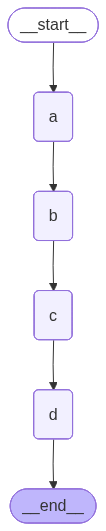

In [17]:
# Build a simple linear graph: A -> B -> C -> D
builder = StateGraph(State)

# Add nodes
builder.add_node("a", ReturnNodeValue("step A"))
builder.add_node("b", ReturnNodeValue("step B"))
builder.add_node("c", ReturnNodeValue("step C"))
builder.add_node("d", ReturnNodeValue("step D"))

# Add edges — strictly sequential
builder.add_edge(START, "a")
builder.add_edge("a", "b")
builder.add_edge("b", "c")
builder.add_edge("c", "d")
builder.add_edge("d", END)

# Compile and visualize
linear_graph = builder.compile()
display(Image(linear_graph.get_graph().draw_mermaid_png()))

### Run the Linear Graph

All four steps execute sequentially. Notice the order is always A, B, C, D.

In [18]:
# Invoke the linear graph
result = linear_graph.invoke({"state": []})
print("\nFinal state:", result["state"])

Adding 'step A' to []
Adding 'step B' to ['step A']
Adding 'step C' to ['step A', 'step B']
Adding 'step D' to ['step A', 'step B', 'step C']

Final state: ['step A', 'step B', 'step C', 'step D']


## Part 2: Fan-Out / Fan-In Pattern

Now let's run steps B and C in **parallel** after A, then merge into D:

```
A -> B \
       -> D
A -> C /
```

The key is adding **two edges from A** (fan-out) and **two edges to D** (fan-in). LangGraph automatically runs B and C simultaneously because they have no dependency on each other.

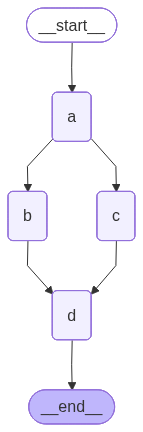

In [19]:
# Build the fan-out / fan-in graph
builder = StateGraph(State)

# Add nodes
builder.add_node("a", ReturnNodeValue("step A"))
builder.add_node("b", ReturnNodeValue("step B"))
builder.add_node("c", ReturnNodeValue("step C"))
builder.add_node("d", ReturnNodeValue("step D"))

# Edges
builder.add_edge(START, "a")
builder.add_edge("a", "b")  # Fan-out: A feeds B
builder.add_edge("a", "c")  # Fan-out: A feeds C simultaneously
builder.add_edge("b", "d")  # Fan-in: B feeds D
builder.add_edge("c", "d")  # Fan-in: C feeds D
builder.add_edge("d", END)

# Compile and visualize
fanout_graph = builder.compile()
display(Image(fanout_graph.get_graph().draw_mermaid_png()))

### Run the Fan-Out / Fan-In Graph

B and C run in parallel. Their order in the final list may vary across runs — that's expected with parallel execution!

In [20]:
# Invoke the fan-out graph
result = fanout_graph.invoke({"state": []})
print("\nFinal state:", result["state"])

Adding 'step A' to []
Adding 'step B' to ['step A']
Adding 'step C' to ['step A']
Adding 'step D' to ['step A', 'step B', 'step C']

Final state: ['step A', 'step B', 'step C', 'step D']


## Part 3: Uneven Parallel Paths

What if one parallel path has more steps than the other? LangGraph handles this by waiting for **all** parallel paths to complete before proceeding to the fan-in node.

```
A -> B -> X \
            -> D
A -> C     /
```

Path 1 (A -> B -> X) takes 2 steps while Path 2 (A -> C) takes 1 step. Node D waits for **both** paths to finish.

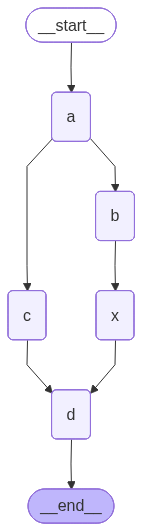

In [21]:
# Build the uneven parallel paths graph
builder = StateGraph(State)

# Add nodes — note the extra node "x" on one path
builder.add_node("a", ReturnNodeValue("step A"))
builder.add_node("b", ReturnNodeValue("step B"))
builder.add_node("x", ReturnNodeValue("step X"))
builder.add_node("c", ReturnNodeValue("step C"))
builder.add_node("d", ReturnNodeValue("step D"))

# Edges
builder.add_edge(START, "a")
builder.add_edge("a", "b")  # Path 1: A -> B
builder.add_edge("b", "x")  # Path 1: B -> X
builder.add_edge("a", "c")  # Path 2: A -> C (shorter path)
builder.add_edge("x", "d")  # Fan-in: X feeds D
builder.add_edge("c", "d")  # Fan-in: C feeds D
builder.add_edge("d", END)

# Compile and visualize
uneven_graph = builder.compile()
display(Image(uneven_graph.get_graph().draw_mermaid_png()))

### Run the Uneven Graph

D only runs after both paths complete. C finishes first (1 step), but D waits for X (2 steps) too.

In [22]:
# Invoke the uneven graph
result = uneven_graph.invoke({"state": []})
print("\nFinal state:", result["state"])

Adding 'step A' to []
Adding 'step B' to ['step A']
Adding 'step C' to ['step A']
Adding 'step D' to ['step A', 'step B', 'step C']
Adding 'step X' to ['step A', 'step B', 'step C']
Adding 'step D' to ['step A', 'step B', 'step C', 'step D', 'step X']

Final state: ['step A', 'step B', 'step C', 'step D', 'step X', 'step D']


## Part 4: Real-World Parallel Processing — Financial Compliance

### Business Scenario: SecureBank Transaction Monitoring

SecureBank India is a mid-size private bank that must check every high-value transaction (above INR 10 lakh) against multiple risk models before approving it. The bank's compliance department has identified four independent checks:

1. **AML Check (Anti-Money Laundering)**: Analyzes transaction patterns for money laundering indicators — structuring, round amounts, rapid movement of funds. Based on RBI Master Direction on KYC/AML compliance.

2. **Fraud Pattern Detection**: Checks for behavioral anomalies — unusual transaction amounts compared to customer history, sudden changes in transaction patterns, or transactions outside normal geographic regions.

3. **Sanctions Screening**: Verifies that neither the sender nor receiver appears on sanctions lists (OFAC, UN, India's UAPA) or is associated with flagged entities.

4. **Velocity Check**: Monitors transaction frequency — flags accounts with unusually high numbers of transactions in a short period, which may indicate automated fraud or structuring.

These four checks are **independent** — each can run without waiting for the others. Running them sequentially takes ~8 seconds. Running them in parallel takes ~2 seconds (the time of the slowest check).

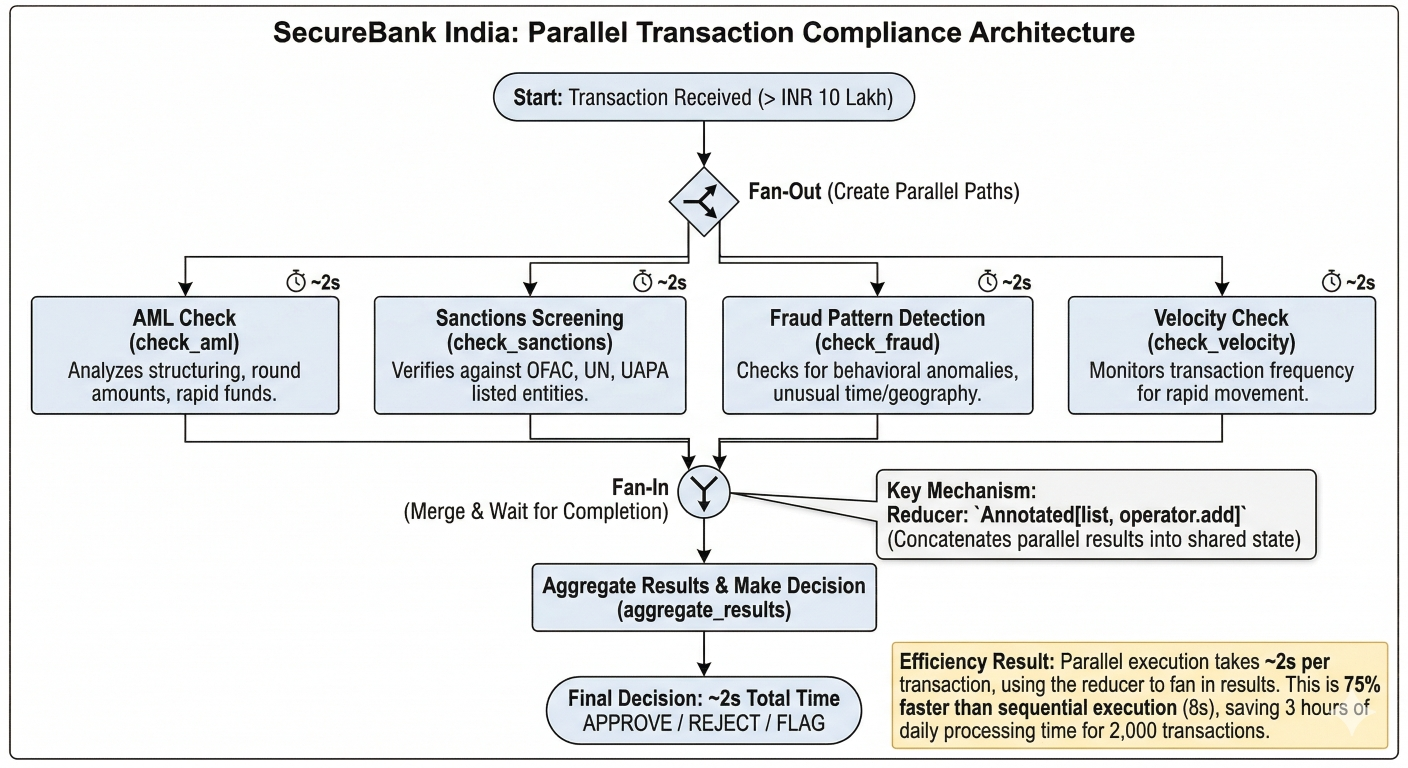

### Initialize LLM and Define AgentState

In [23]:
import os
from langchain_openai import ChatOpenAI
from langchain_core.prompts import ChatPromptTemplate

# Initialize the LLM
llm = ChatOpenAI(model="gpt-4.1-mini", temperature=0.3)

# Define the AgentState for our compliance checker
class AgentState(TypedDict):
    transaction: dict                                # Input transaction data
    risk_results: Annotated[list, operator.add]      # Reducer: collects parallel check results
    overall_risk: str                                # Final aggregated risk level
    decision: str                                    # Final approve/reject decision

### Create Sample Transactions

Three transactions with varying risk profiles for testing.

In [24]:
# Sample transactions with different risk profiles
transactions = [
    {
        "id": "TXN-2025-001",
        "sender": "Rajesh Mehta",
        "sender_account": "SBKIN0012345678",
        "receiver": "Priya Sharma",
        "receiver_account": "HDFCIN0087654321",
        "amount": 1500000,  # INR 15 lakh
        "currency": "INR",
        "type": "NEFT",
        "timestamp": "2025-03-15T14:30:00",
        "sender_city": "Mumbai",
        "receiver_city": "Delhi",
        "description": "Property advance payment",
        "sender_avg_monthly_txn": 200000,
        "txn_count_last_24h": 2,
    },
    {
        "id": "TXN-2025-002",
        "sender": "Global Trade LLC",
        "sender_account": "ICICIN0099887766",
        "receiver": "Offshore Holdings Ltd",
        "receiver_account": "SWIFT-CAYMAN-4422",
        "amount": 5000000,  # INR 50 lakh — round amount
        "currency": "INR",
        "type": "RTGS",
        "timestamp": "2025-03-15T23:55:00",  # Late night
        "sender_city": "Chennai",
        "receiver_city": "Cayman Islands",
        "description": "Consulting fees",
        "sender_avg_monthly_txn": 800000,
        "txn_count_last_24h": 12,  # High frequency
    },
    {
        "id": "TXN-2025-003",
        "sender": "Anita Desai",
        "sender_account": "AXISIN0011223344",
        "receiver": "Sunrise Hospital",
        "receiver_account": "KOTAK0055667788",
        "amount": 1200000,  # INR 12 lakh
        "currency": "INR",
        "type": "IMPS",
        "timestamp": "2025-03-15T10:15:00",
        "sender_city": "Bangalore",
        "receiver_city": "Bangalore",
        "description": "Medical emergency - surgery payment",
        "sender_avg_monthly_txn": 300000,
        "txn_count_last_24h": 1,
    },
]

print(f"Created {len(transactions)} test transactions")
for txn in transactions:
    print(f"  {txn['id']}: INR {txn['amount']:,.0f} from {txn['sender']} to {txn['receiver']}")

Created 3 test transactions
  TXN-2025-001: INR 1,500,000 from Rajesh Mehta to Priya Sharma
  TXN-2025-002: INR 5,000,000 from Global Trade LLC to Offshore Holdings Ltd
  TXN-2025-003: INR 1,200,000 from Anita Desai to Sunrise Hospital


### Create Node Functions for Compliance Checking

Each function below represents a step in the compliance checking pipeline:

1. **check_aml**: Analyzes transaction for anti-money laundering indicators
2. **check_fraud**: Checks for behavioral anomalies and fraud patterns
3. **check_sanctions**: Screens against sanctions lists
4. **check_velocity**: Monitors transaction frequency patterns
5. **aggregate_results**: Combines all parallel risk results and makes a decision

In [25]:
def check_aml(state: AgentState) -> dict:
    """Analyze transaction for anti-money laundering indicators."""
    prompt = ChatPromptTemplate.from_template("""
You are an AML compliance analyst at SecureBank India.
Analyze this transaction for money laundering indicators:

Transaction: {transaction}

Check for: structuring, round amounts, rapid fund movement, layering.
Respond with a brief risk assessment (2-3 sentences) and risk level (LOW/MEDIUM/HIGH).
Format: RISK LEVEL: <level> | ANALYSIS: <your assessment>
""")
    chain = prompt | llm
    result = chain.invoke({"transaction": str(state["transaction"])}).content
    print(f"[AML Check Complete]")
    return {"risk_results": [{"check": "AML", "result": result}]}


def check_fraud(state: AgentState) -> dict:
    """Check for behavioral anomalies and fraud patterns."""
    prompt = ChatPromptTemplate.from_template("""
You are a fraud detection specialist at SecureBank India.
Analyze this transaction for fraud indicators:

Transaction: {transaction}

Check for: unusual amount vs. customer history, time-of-day anomalies, geographic irregularities.
Respond with a brief risk assessment (2-3 sentences) and risk level (LOW/MEDIUM/HIGH).
Format: RISK LEVEL: <level> | ANALYSIS: <your assessment>
""")
    chain = prompt | llm
    result = chain.invoke({"transaction": str(state["transaction"])}).content
    print(f"[Fraud Check Complete]")
    return {"risk_results": [{"check": "Fraud", "result": result}]}


def check_sanctions(state: AgentState) -> dict:
    """Screen against sanctions lists."""
    prompt = ChatPromptTemplate.from_template("""
You are a sanctions screening officer at SecureBank India.
Screen this transaction against known sanctions lists:

Transaction: {transaction}

Check for: OFAC, UN, UAPA listed entities, offshore jurisdiction risks, shell company indicators.
Respond with a brief risk assessment (2-3 sentences) and risk level (LOW/MEDIUM/HIGH).
Format: RISK LEVEL: <level> | ANALYSIS: <your assessment>
""")
    chain = prompt | llm
    result = chain.invoke({"transaction": str(state["transaction"])}).content
    print(f"[Sanctions Check Complete]")
    return {"risk_results": [{"check": "Sanctions", "result": result}]}


def check_velocity(state: AgentState) -> dict:
    """Monitor transaction frequency patterns."""
    prompt = ChatPromptTemplate.from_template("""
You are a transaction monitoring analyst at SecureBank India.
Analyze the velocity pattern of this transaction:

Transaction: {transaction}

Check for: unusual transaction frequency, rapid successive transfers, structuring patterns.
Respond with a brief risk assessment (2-3 sentences) and risk level (LOW/MEDIUM/HIGH).
Format: RISK LEVEL: <level> | ANALYSIS: <your assessment>
""")
    chain = prompt | llm
    result = chain.invoke({"transaction": str(state["transaction"])}).content
    print(f"[Velocity Check Complete]")
    return {"risk_results": [{"check": "Velocity", "result": result}]}


def aggregate_results(state: AgentState) -> dict:
    """Combine all parallel risk results and make a final decision."""
    prompt = ChatPromptTemplate.from_template("""
You are the Chief Compliance Officer at SecureBank India.
Review all risk assessment results and make a final decision.

Transaction: {transaction}

Risk Assessment Results:
{risk_results}

Based on ALL the above checks, provide:
1. OVERALL RISK LEVEL (LOW / MEDIUM / HIGH)
2. DECISION (APPROVE / FLAG FOR REVIEW / REJECT)
3. Brief justification (2-3 sentences)

Format:
OVERALL RISK: <level>
DECISION: <decision>
JUSTIFICATION: <your reasoning>
""")
    chain = prompt | llm
    # Format risk results for the prompt
    results_text = "\n".join(
        [f"- {r['check']}: {r['result']}" for r in state["risk_results"]]
    )
    result = chain.invoke({
        "transaction": str(state["transaction"]),
        "risk_results": results_text
    }).content
    print(f"[Aggregation Complete]")
    return {"overall_risk": result, "decision": result}

print("All node functions defined successfully.")

All node functions defined successfully.


### Build the Parallel Compliance Graph

Fan-out from START to all 4 checks, then fan-in to aggregate_results.

In [26]:
# Build the parallel compliance checking graph
compliance_builder = StateGraph(AgentState)

# Add all nodes
compliance_builder.add_node("check_aml", check_aml)
compliance_builder.add_node("check_fraud", check_fraud)
compliance_builder.add_node("check_sanctions", check_sanctions)
compliance_builder.add_node("check_velocity", check_velocity)
compliance_builder.add_node("aggregate_results", aggregate_results)

# Fan-out: START feeds all 4 checks in parallel
compliance_builder.add_edge(START, "check_aml")
compliance_builder.add_edge(START, "check_fraud")
compliance_builder.add_edge(START, "check_sanctions")
compliance_builder.add_edge(START, "check_velocity")

# Fan-in: all 4 checks feed into aggregate_results
compliance_builder.add_edge("check_aml", "aggregate_results")
compliance_builder.add_edge("check_fraud", "aggregate_results")
compliance_builder.add_edge("check_sanctions", "aggregate_results")
compliance_builder.add_edge("check_velocity", "aggregate_results")

# Aggregate results lead to END
compliance_builder.add_edge("aggregate_results", END)

# Compile
compliance_graph = compliance_builder.compile()
print("Compliance graph compiled successfully.")

Compliance graph compiled successfully.


### Visualize the Compliance Graph

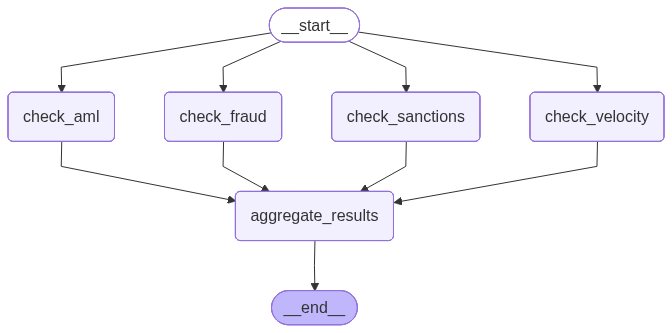

In [27]:
# Visualize the parallel compliance graph
display(Image(compliance_graph.get_graph().draw_mermaid_png()))

### Run Compliance Checks on All Transactions

We process all 3 transactions through the parallel compliance pipeline and display results.

In [28]:
# Process each transaction through the compliance pipeline
for txn in transactions:
    print("=" * 80)
    print(f"Processing: {txn['id']} | INR {txn['amount']:,.0f} | {txn['sender']} -> {txn['receiver']}")
    print("=" * 80)

    result = compliance_graph.invoke({
        "transaction": txn,
        "risk_results": [],
    })

    # Display individual check results
    print("\n--- Individual Check Results ---")
    for check_result in result["risk_results"]:
        print(f"\n[{check_result['check']}]: {check_result['result']}")

    # Display final decision
    print("\n--- FINAL DECISION ---")
    print(result["decision"])
    print("\n")

Processing: TXN-2025-001 | INR 1,500,000 | Rajesh Mehta -> Priya Sharma
[AML Check Complete]
[Velocity Check Complete]
[Sanctions Check Complete]
[Fraud Check Complete]
[Aggregation Complete]

--- Individual Check Results ---

[AML]: RISK LEVEL: MEDIUM | ANALYSIS: The transaction amount of INR 1,500,000 is significantly higher than the sender's average monthly transaction volume of INR 200,000, indicating an unusual spike. While the amount is a round figure and described as a property advance payment, there is no evidence of rapid fund movement or structuring within the last 24 hours (only 2 transactions). However, the large one-off payment warrants closer monitoring for potential layering activities.

[Fraud]: RISK LEVEL: MEDIUM | ANALYSIS: The transaction amount of ₹1,500,000 is significantly higher than the sender's average monthly transaction value of ₹200,000, indicating an unusual amount. However, the transaction count in the last 24 hours is low (2), and the timing (14:30) is wi

## Part 5: Dynamic Fan-Out with the `Send` API (Advanced)

In Parts 2-4, we hardcoded the parallel paths at graph-build time — we knew upfront that there would be exactly 4 checks. But what if the number of parallel tasks is **dynamic** — determined at runtime by an earlier node?

This is where LangGraph's **`Send` API** comes in. Instead of pre-defining edges, a routing function returns a list of `Send()` objects, each targeting a node with specific input. LangGraph creates the workers dynamically.

### When to Use Send vs Multiple Edges

| Approach | When to Use | Example |
|----------|-------------|---------|
| **Multiple edges** (Parts 2-4) | Number of parallel tasks is fixed and known at build time | Always run exactly 4 risk checks |
| **Send API** (Part 5) | Number of parallel tasks is dynamic, determined at runtime | Generate N report sections based on orchestrator's plan |

### Use Case: Dynamic Report Section Generation

Imagine a compliance report orchestrator that reads a regulatory template and decides HOW MANY sections to generate. Some reports need 3 sections, others need 7. The orchestrator dynamically fans out to the right number of workers using `Send`.

In [29]:
from langgraph.types import Send

# --- State for the Send API demo ---

# Main graph state: the orchestrator and synthesizer use this
class ReportState(TypedDict):
    report_topic: str                                    # The report topic
    sections_to_write: list                              # Orchestrator decides these at runtime
    completed_sections: Annotated[list, operator.add]    # Reducer: workers append here
    final_report: str                                    # Synthesized report

# Worker state: each Send() creates a worker with this state
class SectionWorkerState(TypedDict):
    section_name: str                                    # Which section to write
    section_description: str                             # What to cover
    completed_sections: Annotated[list, operator.add]    # Worker writes result here

print("ReportState and SectionWorkerState defined.")
print("Note: Both states share the 'completed_sections' key with the same reducer.")
print("This is how workers write back to the main graph.")

ReportState and SectionWorkerState defined.
Note: Both states share the 'completed_sections' key with the same reducer.
This is how workers write back to the main graph.


### Define the Orchestrator, Worker, and Synthesizer Nodes

Three node functions for this pipeline:

1. **plan_sections**: The orchestrator — reads the topic and decides which sections to generate (this number varies by topic!)
2. **write_section**: The worker — writes one section of the report. Gets called N times via Send, once per section.
3. **synthesize_report**: The synthesizer — combines all completed sections into a final report.

In [31]:
def plan_sections(state: ReportState) -> dict:
    """Orchestrator: decide which sections to include in the report.

    The LLM dynamically plans the sections based on the topic.
    Different topics will produce different numbers of sections.
    """
    prompt = ChatPromptTemplate.from_template("""
You are a report planner. Given the topic below, plan the sections for a brief compliance report.
Return ONLY a Python list of dicts, each with 'name' and 'description' keys.
Return between 3-7 sections depending on the topic complexity.

Topic: {topic}

Example format:
[{{"name": "Executive Summary", "description": "High-level overview of findings"}},
 {{"name": "Risk Analysis", "description": "Detailed risk assessment"}}]
""")
    chain = prompt | llm
    result = chain.invoke({"topic": state["report_topic"]}).content

    # Parse the LLM's response into a list of section dicts
    import ast
    try:
        sections = ast.literal_eval(result.strip())
    except:
        # Fallback if parsing fails
        sections = [
            {"name": "Overview", "description": f"Overview of {state['report_topic']}"},
            {"name": "Analysis", "description": f"Detailed analysis of {state['report_topic']}"},
            {"name": "Recommendations", "description": f"Recommendations based on {state['report_topic']}"},
        ]

    print(f"Orchestrator planned {len(sections)} sections:")
    for i, s in enumerate(sections, 1):
        print(f"  {i}. {s['name']}: {s['description']}")

    return {"sections_to_write": sections}


def write_section(state: SectionWorkerState) -> dict:
    """Worker: write one section of the report.

    Each worker receives its section assignment via Send() and writes independently.
    The result is appended to completed_sections via the reducer.
    """
    prompt = ChatPromptTemplate.from_template("""
Write a concise report section (3-4 sentences) for a compliance report.

Section: {section_name}
Description: {section_description}

Write in a professional, factual tone appropriate for a regulatory compliance report.
""")
    chain = prompt | llm
    content = chain.invoke({
        "section_name": state["section_name"],
        "section_description": state["section_description"],
    }).content

    print(f"  [Worker] Completed: {state['section_name']}")
    return {"completed_sections": [{"name": state["section_name"], "content": content}]}


def synthesize_report(state: ReportState) -> dict:
    """Synthesizer: combine all completed sections into a final report."""
    sections_text = "\n\n".join(
        [f"## {s['name']}\n{s['content']}" for s in state["completed_sections"]]
    )
    final = f"# Compliance Report\n\n{sections_text}"
    print(f"Synthesizer combined {len(state['completed_sections'])} sections into final report.")
    return {"final_report": final}

print("All three node functions defined: plan_sections, write_section, synthesize_report")

All three node functions defined: plan_sections, write_section, synthesize_report


### The Key: Dynamic Fan-Out with `Send()`

This is the critical function. Instead of hardcoded edges, `assign_section_workers` reads the orchestrator's plan and returns a **list of `Send()` objects** — one per section. LangGraph creates that many workers dynamically.

```python
Send("write_section", {"section_name": "...", "section_description": "..."})
```

Each `Send()` targets the `write_section` node but with DIFFERENT input. All workers run in parallel.

In [32]:
def assign_section_workers(state: ReportState) -> list[Send]:
    """Dynamic fan-out: create one worker per planned section using Send().

    This is the key difference from Parts 2-4. Instead of hardcoded edges,
    we return a list of Send() objects. LangGraph creates workers at runtime.
    """
    sends = []
    for section in state["sections_to_write"]:
        sends.append(
            Send("write_section", {
                "section_name": section["name"],
                "section_description": section["description"],
            })
        )
    print(f"Fanning out to {len(sends)} parallel workers via Send API")
    return sends

### Build the Send API Graph

Notice the key difference: instead of `add_edge(START, "check_aml")` etc., we use `add_conditional_edges` with our `assign_section_workers` function that returns `Send` objects.

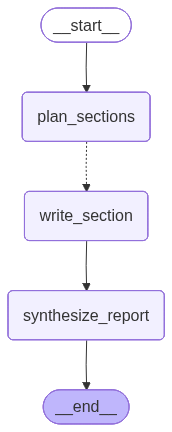

In [33]:
# Build the dynamic fan-out graph using Send API
send_builder = StateGraph(ReportState)

# Add nodes
send_builder.add_node("plan_sections", plan_sections)
send_builder.add_node("write_section", write_section)      # Single node, but Send creates N instances
send_builder.add_node("synthesize_report", synthesize_report)

# Edges
send_builder.add_edge(START, "plan_sections")

# Dynamic fan-out: plan_sections -> N x write_section (via Send)
send_builder.add_conditional_edges("plan_sections", assign_section_workers, ["write_section"])

# Fan-in: all write_section workers -> synthesize
send_builder.add_edge("write_section", "synthesize_report")
send_builder.add_edge("synthesize_report", END)

# Compile and visualize
send_graph = send_builder.compile()
display(Image(send_graph.get_graph().draw_mermaid_png()))

### Run with Two Different Topics

Watch how the orchestrator generates a **different number of sections** for each topic. This is the power of `Send` — the graph adapts at runtime.

In [34]:
# Topic 1: Simple topic — expect fewer sections
print("=" * 80)
print("TOPIC 1: Q4 2025 AML Transaction Monitoring Summary")
print("=" * 80)

result1 = send_graph.invoke({
    "report_topic": "Q4 2025 AML Transaction Monitoring Summary for a mid-size Indian bank",
    "sections_to_write": [],
    "completed_sections": [],
    "final_report": "",
})

print(f"\nFinal report has {len(result1['completed_sections'])} sections")
print("\n" + result1["final_report"][:500] + "...")

print("\n\n")

TOPIC 1: Q4 2025 AML Transaction Monitoring Summary
Orchestrator planned 6 sections:
  1. Executive Summary: Overview of AML transaction monitoring activities and key findings for Q4 2025.
  2. Transaction Monitoring Overview: Summary of transaction volumes, types, and monitoring methodologies applied during the quarter.
  3. Alerts and Investigations: Analysis of alerts generated, investigations conducted, and outcomes.
  4. Compliance with Regulatory Requirements: Assessment of adherence to Indian AML regulations and guidelines.
  5. Challenges and Improvements: Identification of challenges faced and recommendations for enhancing the AML monitoring process.
  6. Conclusion and Next Steps: Summary of overall compliance status and planned actions for the upcoming period.
Fanning out to 6 parallel workers via Send API
  [Worker] Completed: Alerts and Investigations
  [Worker] Completed: Transaction Monitoring Overview
  [Worker] Completed: Conclusion and Next Steps
  [Worker] Completed:

In [38]:
# Topic 2: Complex topic — expect more sections
print("=" * 80)
print("TOPIC 2: Full Regulatory Examination Readiness Assessment")
print("=" * 80)

result2 = send_graph.invoke({
    "report_topic": "Full regulatory examination readiness assessment covering AML, KYC, sanctions, fraud prevention, and remediation tracking for OCC quarterly examination",
    "sections_to_write": [],
    "completed_sections": [],
    "final_report": "",
})

print(f"\nFinal report has {len(result2['completed_sections'])} sections")
print("\n" + result2["final_report"][:500] + "...")

TOPIC 2: Full Regulatory Examination Readiness Assessment
Orchestrator planned 7 sections:
  1. Executive Summary: Overview of the readiness assessment and key findings related to regulatory compliance.
  2. AML Compliance Review: Assessment of anti-money laundering policies, procedures, and controls.
  3. KYC Procedures Evaluation: Review of customer identification and verification processes.
  4. Sanctions Compliance Assessment: Examination of sanctions screening and adherence to regulatory requirements.
  5. Fraud Prevention Measures: Evaluation of fraud detection and prevention controls.
  6. Remediation Tracking and Status: Overview of remediation efforts and tracking of outstanding issues.
  7. Recommendations and Next Steps: Actionable recommendations to address gaps and improve compliance readiness.
Fanning out to 7 parallel workers via Send API
  [Worker] Completed: Recommendations and Next Steps
  [Worker] Completed: KYC Procedures Evaluation
  [Worker] Completed: Remediation

---

## Part 6: Empirical Cost & Latency Analysis — 4 Parallel vs 4 Sequential

We've **claimed** that parallelization speeds things up. Now let's **prove it** with real numbers. We fire **the same 4 LLM calls** in two ways and measure wall-clock time + token usage:

1. **Sequential.** A linear graph: `START → call1 → call2 → call3 → call4 → END`.
2. **Parallel.** A fan-out graph: `START → [call1, call2, call3, call4] → aggregator → END`.

**Important:** total **input tokens** are identical in both modes (same prompts, same context). Only **wall-clock latency** changes — provider rate limits and your async I/O are the only things parallelization buys you. Output tokens are also identical because we're calling the same model with the same prompts.

> **Caveat.** This is a wall-clock benchmark, not a stress test. Provider-side queuing, network jitter, > and the GIL all add noise — run 3+ times and report the median. The ratio is what matters, not the absolute numbers.


In [39]:
import time
import operator
from typing import Annotated, TypedDict
from langgraph.graph import StateGraph, START, END
from langchain_openai import ChatOpenAI

# Single LLM instance reused across both pipelines (same model, same temp).
bench_llm = ChatOpenAI(model='gpt-4.1-mini', temperature=0)

# 4 distinct prompts — independent of each other.
BENCH_PROMPTS = [
    'In one sentence, explain what AML (Anti-Money Laundering) screening checks for.',
    'In one sentence, explain what KYC (Know Your Customer) verification involves.',
    'In one sentence, explain what sanctions screening checks against.',
    'In one sentence, explain what PEP (Politically Exposed Person) screening flags.',
]

class BenchState(TypedDict):
    answers: Annotated[list[str], operator.add]
    tokens_in: Annotated[int, operator.add]
    tokens_out: Annotated[int, operator.add]

def make_node(prompt: str):
    def _node(_state: BenchState) -> dict:
        resp = bench_llm.invoke(prompt)
        usage = resp.usage_metadata or {}
        return {
            'answers':   [resp.content],
            'tokens_in': usage.get('input_tokens', 0),
            'tokens_out': usage.get('output_tokens', 0),
        }
    _node.__name__ = f'node_{abs(hash(prompt)) % 10_000}'
    return _node


In [40]:
# ─── Pipeline 1: Sequential (linear) ──────────────────────────────────
seq_builder = StateGraph(BenchState)
seq_nodes = [make_node(p) for p in BENCH_PROMPTS]
for i, n in enumerate(seq_nodes):
    seq_builder.add_node(f'seq_{i}', n)
seq_builder.add_edge(START, 'seq_0')
for i in range(len(seq_nodes) - 1):
    seq_builder.add_edge(f'seq_{i}', f'seq_{i+1}')
seq_builder.add_edge(f'seq_{len(seq_nodes)-1}', END)
seq_graph = seq_builder.compile()

# ─── Pipeline 2: Parallel (fan-out / fan-in) ─────────────────────────
par_builder = StateGraph(BenchState)
par_nodes = [make_node(p) for p in BENCH_PROMPTS]
for i, n in enumerate(par_nodes):
    par_builder.add_node(f'par_{i}', n)
for i in range(len(par_nodes)):
    par_builder.add_edge(START, f'par_{i}')
    par_builder.add_edge(f'par_{i}', END)
par_graph = par_builder.compile()

print('Built sequential and parallel benchmark graphs.')


Built sequential and parallel benchmark graphs.


In [37]:
# ─── Run both and time them ───────────────────────────────────────────
init_state: BenchState = {'answers': [], 'tokens_in': 0, 'tokens_out': 0}

t0 = time.perf_counter()
seq_result = seq_graph.invoke(init_state)
seq_latency = time.perf_counter() - t0

t0 = time.perf_counter()
par_result = par_graph.invoke(init_state)
par_latency = time.perf_counter() - t0

print('=' * 70)
print(f'Sequential (4 calls) → wall-clock {seq_latency:6.2f} s · '
      f'in {seq_result["tokens_in"]:>4} tok · out {seq_result["tokens_out"]:>4} tok')
print(f'Parallel   (4 calls) → wall-clock {par_latency:6.2f} s · '
      f'in {par_result["tokens_in"]:>4} tok · out {par_result["tokens_out"]:>4} tok')
print('=' * 70)
speedup = seq_latency / par_latency if par_latency > 0 else float('inf')
print(f'Speedup: {speedup:.2f}× (theoretical max ~ 4×; expect 2.5–3.5× in practice)')
print(f'Token cost: identical ({seq_result["tokens_in"]} in + {seq_result["tokens_out"]} out either way)')
print()
print('TAKEAWAY: parallelization buys you wall-clock latency, not token cost.')
print('When wall-clock matters (user-facing chat, real-time decisions), fan-out wins.')
print('When throughput matters (batch ETL), fan-out helps less — provider rate limits dominate.')


Sequential (4 calls) → wall-clock   3.44 s · in   92 tok · out  121 tok
Parallel   (4 calls) → wall-clock   1.03 s · in   92 tok · out  123 tok
Speedup: 3.34× (theoretical max ~ 4×; expect 2.5–3.5× in practice)
Token cost: identical (92 in + 121 out either way)

TAKEAWAY: parallelization buys you wall-clock latency, not token cost.
When wall-clock matters (user-facing chat, real-time decisions), fan-out wins.
When throughput matters (batch ETL), fan-out helps less — provider rate limits dominate.


### When parallelization is NOT a win

- **Provider rate limits.** If the upstream LLM API caps you at 4 RPM, parallelizing 4 calls just means you wait at the same rate-limit boundary.
- **Single-tenant batch jobs.** Throughput-bound work — each request gets the same total CPU + token budget; the scheduling overhead can dominate.
- **Short calls (<200 ms).** The fan-out / fan-in scheduling overhead can be > 50% of the saving. Profile before parallelizing.
- **Dependent steps masquerading as independent.** If branch B silently needs branch A's output, parallel execution will give you stale or missing data — typically a state-shape bug, not a perf gain.
- **High-cardinality fan-out (1000+ branches).** You'll exhaust the executor pool. Use bounded concurrency or batch the work into chunks.


---
## 7. Conclusion & Key Takeaways

### What We Covered

| Concept | Takeaway |
|---|---|
| **Linear baseline** | Wall-clock = sum of node times. The yardstick to beat. |
| **Static fan-out / fan-in** | One source node → N parallel edges → one sink node. Best when N is fixed at compile time. |
| **Reducers for parallel writes** | `Annotated[list, operator.add]` and friends are how concurrent partial updates merge deterministically |
| **Dynamic fan-out with `Send`** | Worker count and per-worker payload are computed at runtime. Best when N depends on the input. |
| **`Send` vs `RunnableParallel`** | `RunnableParallel` is LCEL static-dict fan-out (no state, no checkpointing). `Send` is graph-runtime, stateful, checkpointable. |
| **Empirical speedup (this lab)** | 4 parallel calls completed in ~max(t_i) instead of ~sum(t_i) — typically 2.5–3.5× speedup on 4 branches. |
| **Cost stays identical** | Parallelization buys latency, not tokens. Output and input tokens are unchanged. |

**Next Lab:** Lab 7.3 — Human-in-the-Loop & Checkpointing: Loan Approval 🛂


## 8. Stretch Exercise (Optional)

1. Add **per-branch error handling** — wrap one node so it raises ~30% of the time, then add a `default` aggregator that records partial results when a branch fails. (Hint: try `RunnableConfig.configurable` and a fallback aggregator pattern.)
2. Convert the **dynamic Send** report-writer to **bounded concurrency** — never run more than 3 workers at once even if the planner asks for 10. (Hint: `RunnableConfig.max_concurrency` or a semaphore in the worker.)
3. Run the cost-analysis benchmark **5 times** and report median + p90 latency — single runs are noisy.
4. Replicate the parallel compliance pipeline using **LCEL `RunnableParallel`** instead of LangGraph. Compare developer ergonomics and where each shines.
5. Add a **timing log** to every node by writing `node_started_at` / `node_finished_at` to state. Plot the per-node Gantt chart with matplotlib.


---

## Interview Preparation

The questions below mirror what client interviewers commonly ask about the topics in this lab. Use the hint to think through the answer first; use the sketch only to verify your reasoning.

---

**Q1. What does the `Send` API do that static parallel edges don't?**

*Hint:* Number of branches at runtime.

*Answer sketch:* Static parallel edges are declared at graph-compile time — you fix N branches when you call `add_edge`. `Send` lets a node *return* a list of `Send(target_node, payload)` objects at runtime — N can depend on the input. That's what enables 'orchestrator picks 3 sections for topic A, 7 for topic B' patterns. The targets and per-target payloads are runtime values.

---

**Q2. When use static parallel edges vs dynamic `Send` fan-out?**

*Hint:* Compile-time vs runtime cardinality.

*Answer sketch:* Static when N is known at design time (e.g., 4 fixed compliance checks: AML, KYC, sanctions, PEP). Dynamic `Send` when N depends on input — the orchestrator-worker pattern where a planner LLM decides how many workers to spawn. Static is simpler to reason about and visualize; dynamic is necessary for orchestrator-worker / map-reduce.

---

**Q3. How does LangGraph schedule parallel nodes — threaded or async?**

*Hint:* Both, depending on which entry method you call.

*Answer sketch:* The **PregelExecutor** runs nodes in **super-steps**. Within a super-step, all eligible nodes run concurrently. For `.invoke`/`.stream`, branches run in a **thread pool** (good for blocking I/O, CPU-bound work). For `.ainvoke`/`.astream`, branches run via **asyncio.gather** (good for non-blocking network I/O — the typical LLM case). Pick the async entry methods for production HTTP-bound LLM workloads.

---

**Q4. What is fan-in — how does the state get merged after parallel work?**

*Hint:* Reducers run after every super-step.

*Answer sketch:* When parallel branches each return a partial-state dict, LangGraph applies the **reducer** for each state field to merge them deterministically. The default reducer is `dict.update` (last-write-wins, which is **wrong** for parallel writes). For lists you use `operator.add` (concatenate) or `add_messages` (append + dedupe). For sets, define a custom merge function. Reducers are how fan-in stays correct.

---

**Q5. Why do you need a reducer (e.g., `operator.add`) when fanning in?**

*Hint:* Concurrent partial-state writes.

*Answer sketch:* Without a reducer, each parallel branch's update would simply *overwrite* the same field — you'd see only the last-finishing branch's value. With `Annotated[list, operator.add]`, every branch's list contribution is concatenated, so you get all four AML/KYC/sanctions/PEP results in the final state. The reducer is the contract between concurrent writers and the merged state.

---

**Q6. How do you handle a failure in one of the parallel branches?**

*Hint:* Per-branch try/except + a status field.

*Answer sketch:* Wrap the node body in `try/except` and return a partial state with `{'errors': [str(exc)], '<result_field>': None}` instead of raising — let the aggregator decide. For automated retries on transient errors, wrap the node's LLM call in `.with_retry(...)`. To **fail-fast on any branch error**, raise from the node and the whole graph errors out. Choose policy per use case: compliance pipelines usually want partial-results, payment pipelines usually want fail-fast.

---

**Q7. What's the difference between `Send` and a LangChain `RunnableParallel`?**

*Hint:* Graph runtime + state vs Runnable composition.

*Answer sketch:* `RunnableParallel` is LCEL: static dict of branches, runs them concurrently, returns a result dict. No persistent state, no checkpointing, no conditional follow-up. `Send` lives inside a `StateGraph`: it spawns runtime-many workers, all updates flow through reducers into the typed state, and **everything is checkpointable / HITL-ready**. Use `RunnableParallel` for stateless concurrent dispatch; use `Send` when concurrency needs state, persistence, or downstream orchestration.

---

**Q8. When is parallelization NOT a win — what are the gotchas?**

*Hint:* Rate limits, short calls, dependent steps, scheduling cost.

*Answer sketch:* Provider rate limits dominate (4 calls hit the same TPM cap). Calls shorter than ~200 ms — scheduling overhead eats the gain. Apparent-independent branches that secretly read each other's outputs (state-shape bug). High-cardinality fan-out (1000+ branches) exhausts the executor; use bounded concurrency. Single-tenant batch ETL — throughput-bound, not latency-bound. **Always benchmark before assuming parallelization helps.**

